# **Inisialisasi Sistem Mesin AI**

In [ ]:
# ==========================================
# VoxSim‑Replica - Zero Loss Chunk Processing + PDF + Graph
# Greedy Decoding (Deterministik, Tanpa Halusinasi)
# ==========================================

import sys, subprocess, importlib, os, textwrap, unicodedata

def install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Pastikan bitsandbytes terinstall
try:
    import bitsandbytes
except ImportError:
    print("⚠️ bitsandbytes tidak ditemukan. Menginstall...")
    install("bitsandbytes>=0.46.1")
    print("✅ bitsandbytes berhasil diinstall. Silakan RESTART runtime (Runtime → Restart runtime) dan jalankan ulang sel ini.")
    import os
    os._exit(0)

packages = [
    "transformers", "accelerate", "bitsandbytes", "networkx", "matplotlib",
    "newspaper3k", "beautifulsoup4", "lxml",
    "PyPDF2", "python-docx", "fpdf2"
]
for pkg in packages:
    try:
        importlib.import_module(pkg.replace("-", "_"))
    except ImportError:
        install(pkg)

# **Jalankan Model Prediksi Simulasi**

Loading VoxSim AI...
Mencoba load model dalam 4-bit...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

✅ Model berhasil di-load dalam 4-bit.
Model siap digunakan dengan quantization: 4-bit


Pilih sumber isu:
1. Teks bebas
2. URL berita
3. Upload file (ketik: file)
> Jakarta, CNBC Indonesia - Nilai tukar rupiah masih terus tertekan terhadap dolar Amerika Serikat (AS), bahkan sempat menembus level Rp 17.700 per US$. Di saat bersamaan, defisit neraca transaksi berjalan (current account deficit/ CAD) Indonesia pada kuartal I-2026 juga tembus hingga US$ 4 miliar atau 1,1% dari PDB pada kuartal I-2026. Ini adalah defisit terbesar sejak kuartal IV-2019. Ekonom Maybank Myrdal Gunarto menilai tekanan terhadap rupiah saat ini dipicu kombinasi faktor global dan domestik. Terutama, derasnya arus keluar modal asing atau hot money outflow dari pasar keuangan Indonesia.  Selain faktor global, investor asing juga disebut masih cenderung berhati-hati terhadap Indonesia di tengah banyaknya kebijakan baru yang dinilai memengaruhi proses bisnis, seperti pembentukan BUMN ekspor dan kebijakan DHE SDA terbar

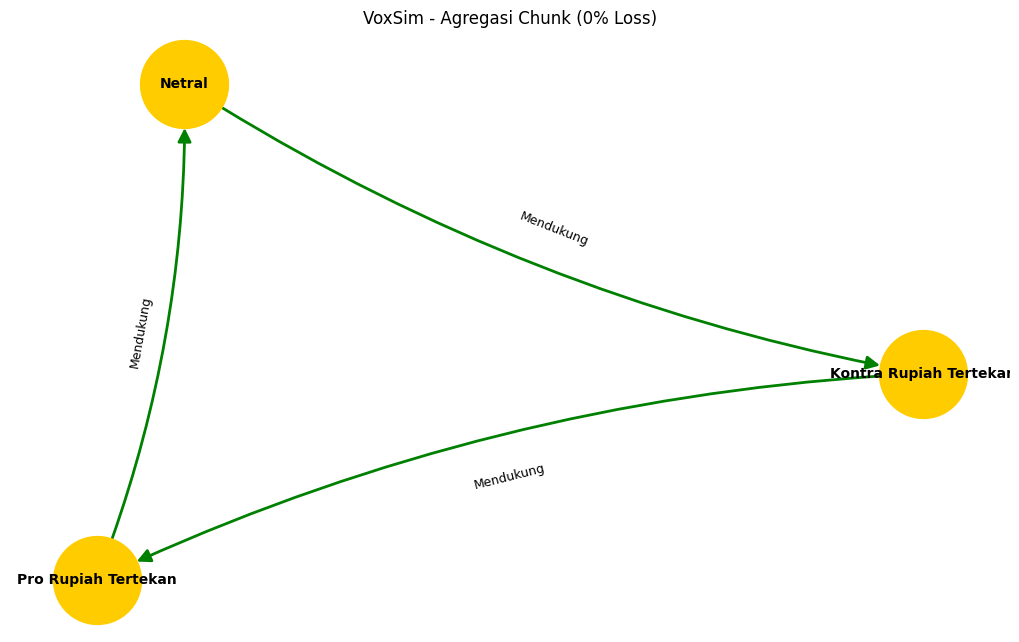


✅ Laporan PDF disimpan sebagai 'laporan_sentimen_voxsim.pdf' (termasuk grafik visualisasi)


/tmp/ipykernel_2408/890357266.py:410: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "LAMPIRAN: GRAFIK INTERAKSI AGEN", ln=True, align="C")
/tmp/ipykernel_2408/890357266.py:418: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=True use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, caption, ln=True, align="C")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import networkx as nx
import matplotlib.pyplot as plt
import json, re, requests
from bs4 import BeautifulSoup
from fpdf import FPDF

try:
    from newspaper import Article
    HAS_NEWSPAPER = True
except:
    HAS_NEWSPAPER = False
try:
    from PyPDF2 import PdfReader
except:
    PdfReader = None
try:
    import docx as docx_lib
except:
    docx_lib = None
try:
    from google.colab import files
    IN_COLAB = True
except:
    IN_COLAB = False

# ========== 1. Load Model dengan Fallback Quantization ==========
print("Loading VoxSim AI...")
model_name = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

quant_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

quant_config_8bit = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_threshold=6.0
)

model = None
used_quant = None

try:
    print("Mencoba load model dalam 4-bit...")
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=quant_config_4bit,
        device_map="auto",
        torch_dtype=torch.float16
    )
    used_quant = "4-bit"
    print("✅ Model berhasil di-load dalam 4-bit.")
except Exception as e:
    print(f"⚠️ 4-bit gagal: {e}")
    print("Mencoba load model dalam 8-bit...")
    try:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            quantization_config=quant_config_8bit,
            device_map="auto",
            torch_dtype=torch.float16
        )
        used_quant = "8-bit"
        print("✅ Model berhasil di-load dalam 8-bit.")
    except Exception as e2:
        print(f"⚠️ 8-bit juga gagal: {e2}")
        print("Mencoba load model tanpa quantization (float16) - mungkin OOM untuk dokumen besar.")
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            torch_dtype=torch.float16,
            device_map="auto"
        )
        used_quant = "float16 (no quantization)"
        print("✅ Model berhasil di-load dalam float16.")

if model is None:
    raise RuntimeError("Gagal memuat model dalam segala mode.")

model.eval()
print(f"Model siap digunakan dengan quantization: {used_quant}\n")

MAX_INPUT_TOKENS = 2000

def potong_teks_menurut_token(teks, max_tokens=MAX_INPUT_TOKENS):
    tokens = tokenizer.encode(teks)
    if len(tokens) <= max_tokens:
        return teks
    truncated = tokens[-max_tokens:]
    return tokenizer.decode(truncated, skip_special_tokens=True)

def panggil_ai(prompt_text, max_new_tokens=150, potong_input=True):
    """Greedy decoding – deterministik, tanpa halusinasi."""
    torch.cuda.empty_cache()
    if potong_input:
        prompt_text = potong_teks_menurut_token(prompt_text, MAX_INPUT_TOKENS)
    messages = [{"role": "user", "content": prompt_text}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    with torch.inference_mode():
        generated_ids = model.generate(
            **model_inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,               # greedy, deterministik
            pad_token_id=tokenizer.eos_token_id,
            use_cache=True
        )
    output_ids = generated_ids[:, model_inputs['input_ids'].shape[1]:]
    response = tokenizer.batch_decode(output_ids, skip_special_tokens=True)[0]
    torch.cuda.empty_cache()
    return response.strip()

def safe_parse_json(text):
    text = re.sub(r'```(?:json)?\s*', '', text)
    text = text.replace('```', '').strip()
    match = re.search(r'\{.*\}', text, re.DOTALL)
    json_candidate = match.group() if match else text
    json_candidate = re.sub(r',\s*}', '}', json_candidate)
    json_candidate = re.sub(r',\s*]', ']', json_candidate)
    return json.loads(json_candidate)

def buat_agen_otomatis(topik_isu):
    prompt = f"""Kamu adalah sosiolog dan analis pasar ahli.
Berdasarkan isu/topik ini: "{topik_isu}"
Tentukan 3 karakter publik berbeda (1 pro, 1 kontra, 1 netral).
Berikan HANYA JSON valid, tanpa teks lain:
{{
    "Agen_A": {{"role": "...", "persona": "..."}},
    "Agen_B": {{"role": "...", "persona": "..."}},
    "Agen_C": {{"role": "...", "persona": "..."}}
}}"""
    jawaban = panggil_ai(prompt, max_new_tokens=200, potong_input=False)
    try:
        data = safe_parse_json(jawaban)
        keys = list(data.keys())
        if len(keys) >= 3:
            return {f"Agen_{chr(65+i)}": data[k] for i, k in enumerate(keys[:3])}
        raise ValueError("Kurang dari 3 agen")
    except:
        print("⚠️ Gagal parsing JSON, pakai profil cadangan.")
        return {
            "Agen_A": {"role": "Pengamat Industri", "persona": "Fokus efisiensi pasar, rasional, kritis."},
            "Agen_B": {"role": "Masyarakat Konsumen", "persona": "Emosional, mementingkan biaya, reaktif."},
            "Agen_C": {"role": "Pelaku Bisnis Lokal", "persona": "Khawatir margin, cemas, mencari solusi."}
        }

def ambil_teks_berita(url, max_chars=3000):
    if HAS_NEWSPAPER:
        try:
            a = Article(url)
            a.download()
            a.parse()
            return f"Judul: {a.title}\n\n{a.text}"[:max_chars]
        except: pass
    try:
        r = requests.get(url, headers={'User-Agent': 'Mozilla/5.0'}, timeout=10)
        soup = BeautifulSoup(r.text, 'html.parser')
        judul = soup.find('h1')
        judul = judul.get_text().strip() if judul else ""
        teks = ' '.join(p.get_text() for p in soup.find_all('p'))
        return f"Judul: {judul}\n\n{teks}"[:max_chars]
    except:
        return None

def ekstrak_teks_dari_file(nama_file, isi_bytes):
    nama = nama_file.lower()
    if nama.endswith('.txt'):
        try: return isi_bytes.decode('utf-8')
        except: return isi_bytes.decode('latin-1')
    elif nama.endswith('.pdf'):
        if PdfReader is None:
            raise ImportError("PyPDF2 tidak ada")
        import io
        reader = PdfReader(io.BytesIO(isi_bytes))
        return "\n".join([p.extract_text() or "" for p in reader.pages])
    elif nama.endswith('.docx'):
        if docx_lib is None:
            raise ImportError("python-docx tidak ada")
        import io
        d = docx_lib.Document(io.BytesIO(isi_bytes))
        return "\n".join([p.text for p in d.paragraphs])
    else:
        try: return isi_bytes.decode('utf-8')
        except: raise ValueError("Format tidak didukung")

def dapatkan_isu():
    print("\nPilih sumber isu:\n1. Teks bebas\n2. URL berita\n3. Upload file (ketik: file)")
    p = input("> ").strip()
    if p.lower() == 'file':
        if not IN_COLAB:
            path = input("Path file: ").strip()
            with open(path, 'rb') as f:
                data = f.read()
            nama = path.split('/')[-1]
        else:
            print("📂 Silakan upload file...")
            uploaded = files.upload()
            if not uploaded:
                print("Tidak ada file.")
                return dapatkan_isu()
            nama = list(uploaded.keys())[0]
            data = uploaded[nama]
        teks = ekstrak_teks_dari_file(nama, data)
        print(f"✅ {len(teks)} karakter diekstrak.")
        return teks
    elif p.lower().startswith("http"):
        konten = ambil_teks_berita(p, max_chars=8000)
        if konten:
            isu = panggil_ai(f"Ringkas isu dari berita ini:\n{konten}", max_new_tokens=100, potong_input=True)
            return isu if isu else "Default"
        return "Default"
    elif p == "":
        return "Pelemahan nilai tukar rupiah saat ini didorong oleh kombinasi faktor global dan domestik."
    else:
        return p

# ========== Zero‑Loss Chunk Processing (Cepat + Greedy) ==========
def jalankan_voxsim_tanpa_loss(isu):
    tokens = tokenizer.encode(isu)
    chunk_size = 30000
    chunks = [tokens[i:i+chunk_size] for i in range(0, len(tokens), chunk_size)]
    print(f"📄 Dokumen {len(tokens)} token, dibagi menjadi {len(chunks)} chunk.")

    first_chunk_text = tokenizer.decode(chunks[0], skip_special_tokens=True)[:2000]
    agents = buat_agen_otomatis(first_chunk_text)
    for k,v in agents.items():
        print(f"{k}: {v['role']} ({v['persona']})")

    all_opinions = {name: [] for name in agents}
    all_edges = []  # (pelaku, target, label, respons)

    for idx, chunk_tokens in enumerate(chunks):
        chunk_text = tokenizer.decode(chunk_tokens, skip_special_tokens=True)
        print(f"\n--- Chunk {idx+1}/{len(chunks)} ---")

        opini_chunk = {}
        for name, profile in agents.items():
            prompt = f"{profile['role']} ({profile['persona']}). Berdasarkan teks berikut: {chunk_text[:2000]}\nOpini singkat (max 30 kata):"
            opini = panggil_ai(prompt, max_new_tokens=50, potong_input=True)
            opini_chunk[name] = opini
            all_opinions[name].append(opini)
            print(f"  {profile['role']}: {opini[:80]}...")

        daftar = list(agents.keys())
        urutan = [(daftar[1], daftar[0]), (daftar[2], daftar[1]), (daftar[0], daftar[2])]
        for pelaku, target in urutan:
            prompt = f"{agents[pelaku]['role']} menanggapi '{opini_chunk[target]}'. Tanggapi dalam 1 kalimat, lalu akhiri dengan [MENDUKUNG] atau [MENENTANG]."
            respons = panggil_ai(prompt, max_new_tokens=60, potong_input=False)
            # Ekstrak label dari kurung siku
            if "[MENDUKUNG]" in respons.upper():
                label = "Mendukung"
            elif "[MENENTANG]" in respons.upper():
                label = "Menentang"
            else:
                label = "Netral"
            respons_clean = respons.replace("[MENDUKUNG]", "").replace("[MENENTANG]", "").strip()
            all_edges.append((pelaku, target, label, respons_clean))
            print(f"  {agents[pelaku]['role']} → {agents[target]['role']}: {label}")

    # Gabungkan opini dari semua chunk
    final_opinions = {}
    for name, op_list in all_opinions.items():
        unik = []
        for op in op_list:
            if op not in unik:
                unik.append(op)
        final_opinions[name] = " || ".join(unik) if len(unik) > 1 else unik[0]

    # Graf agregasi
    G = nx.DiGraph()
    for name, profile in agents.items():
        G.add_node(name, role=profile['role'], opinion=final_opinions[name])

    edge_votes = {}
    for pelaku, target, label, resp in all_edges:
        key = (pelaku, target)
        if key not in edge_votes:
            edge_votes[key] = {'Mendukung':0, 'Menentang':0, 'responses':[]}
        edge_votes[key][label] += 1
        edge_votes[key]['responses'].append(resp)

    for (u,v), votes in edge_votes.items():
        final_label = 'Mendukung' if votes['Mendukung'] >= votes['Menentang'] else 'Menentang'
        G.add_edge(u, v, label=final_label, responses=votes['responses'])

    # Siapkan data untuk laporan
    edge_summary = []
    for u,v,d in G.edges(data=True):
        edge_summary.append(f"- {agents[u]['role']} {d['label'].lower()} pendapat {agents[v]['role']} ({len(d['responses'])} chunk).")
    rangkuman_edges = "\n".join(edge_summary)
    opini_text = "\n".join([f"• {agents[n]['role']}: {op}" for n,op in final_opinions.items()])
    isu_contoh = tokenizer.decode(chunks[0], skip_special_tokens=True)[:1500]

    prompt_laporan = f"""DATA WAJIB (JANGAN MEMBUAT FAKTA BARU):
OPINI AGEN:
{opini_text}

HUBUNGAN:
{rangkuman_edges}

KONTEKS ISU (cuplikan):
{isu_contoh}

Tulis laporan analisis sentimen publik dengan struktur: Abstrak, Pendahuluan, Metodologi, Hasil Analisis Sentimen, Kesimpulan, Rekomendasi Solusi. Bahasa Indonesia formal. Hanya berdasarkan data di atas."""

    laporan = panggil_ai(prompt_laporan, max_new_tokens=1500, potong_input=True)
    print("✅ Laporan selesai.")

    # Visualisasi grafik
    plt.figure(figsize=(10,6))
    pos = nx.spring_layout(G, k=1.0)
    nx.draw(G, pos, labels={k:v['role'] for k,v in agents.items()},
            node_color='#FFCC00', node_size=4000, font_size=10, font_weight='bold',
            edge_color=['red' if G[u][v]['label']=='Menentang' else 'green' for u,v in G.edges()],
            width=2, arrowsize=20, connectionstyle='arc3,rad=0.1')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G,'label'), font_size=9)
    plt.title("VoxSim - Agregasi Chunk (0% Loss)")
    graph_path = "voxsim_graph.png"
    plt.savefig(graph_path, dpi=150, bbox_inches='tight')
    plt.show()

    simpan_laporan_pdf(laporan, agents, isu_contoh, graph_path)
    return agents, G, laporan

# ========== PDF export dengan Unicode ==========
def simpan_laporan_pdf(teks_laporan, agents, isu, graph_image_path):
    def clean_text_for_helvetica(txt):
        replacements = {
            '’': "'", '‘': "'", '“': '"', '”': '"',
            '—': '-', '–': '-', '…': '...', '•': '-',
            '°': ' deg', '™': '(TM)', '®': '(R)', '©': '(C)',
        }
        for bad, good in replacements.items():
            txt = txt.replace(bad, good)
        txt = unicodedata.normalize('NFKD', txt).encode('ascii', 'ignore').decode('ascii')
        return txt

    class PDF(FPDF):
        def __init__(self, font_family, is_unicode_font):
            super().__init__()
            self.font_family = font_family
            self.is_unicode_font = is_unicode_font

        def header(self):
            self.set_font(self.font_family, "B", 11)
            self.cell(0, 8, "Laporan Analisis Sentimen - VoxSim", align="C", new_x="LMARGIN", new_y="NEXT")
            self.ln(4)

        def footer(self):
            self.set_y(-15)
            self.set_font(self.font_family, "I", 8)
            self.cell(0, 10, f"Halaman {self.page_no()}/{{nb}}", align="C")

    dejavu_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf"
    dejavu_bold_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf"
    dejavu_italic_path = "/usr/share/fonts/truetype/dejavu/DejaVuSans-Oblique.ttf"

    if os.path.exists(dejavu_path) and os.path.exists(dejavu_bold_path) and os.path.exists(dejavu_italic_path):
        font_family = "DejaVu"
        is_unicode = True
        pdf = PDF(font_family, is_unicode)
        pdf.add_font(font_family, "", dejavu_path, uni=True)
        pdf.add_font(font_family, "B", dejavu_bold_path, uni=True)
        pdf.add_font(font_family, "I", dejavu_italic_path, uni=True)
    else:
        font_family = "Helvetica"
        is_unicode = False
        pdf = PDF(font_family, is_unicode)

    pdf.alias_nb_pages()
    pdf.add_page()
    pdf.set_auto_page_break(auto=True, margin=20)

    pdf.set_font(font_family, "B", 14)
    pdf.multi_cell(0, 8, "LAPORAN ARTIKEL ANALISIS SENTIMEN PUBLIK", align="C")
    pdf.ln(4)
    pdf.set_font(font_family, "I", 10)
    isu_short = isu[:150] if isu else ""
    if not is_unicode:
        isu_short = clean_text_for_helvetica(isu_short)
    pdf.multi_cell(0, 5, f"Isu (cuplikan): {isu_short}...")
    pdf.ln(6)

    pdf.set_font(font_family, "", 11)
    teks_bersih = teks_laporan.replace("*", "").replace("#", "").replace("**", "")
    paragraf = teks_bersih.split("\n\n")
    for p in paragraf:
        p = p.strip()
        if not p:
            continue
        if not is_unicode:
            p = clean_text_for_helvetica(p)
        is_judul = any(p.startswith(f"{i}.") for i in range(1,10)) or p.startswith("Abstrak") or p.startswith("Pendahuluan") or p.startswith("Metodologi") or p.startswith("Hasil") or p.startswith("Kesimpulan") or p.startswith("Rekomendasi")
        if is_judul:
            pdf.set_font(font_family, "B", 12)
            pdf.multi_cell(0, 6, p)
            pdf.set_font(font_family, "", 11)
        else:
            pdf.multi_cell(0, 5, p)
        pdf.ln(2)

    if os.path.exists(graph_image_path):
        pdf.add_page()
        pdf.set_font(font_family, "B", 14)
        pdf.cell(0, 10, "LAMPIRAN: GRAFIK INTERAKSI AGEN", ln=True, align="C")
        pdf.ln(10)
        pdf.image(graph_image_path, x=20, y=pdf.get_y(), w=170)
        pdf.set_y(pdf.get_y() + 130)
        pdf.set_font(font_family, "I", 10)
        caption = "Gambar 1. Visualisasi hubungan mendukung/menentang antar agen. Panah merah = menentang, hijau = mendukung."
        if not is_unicode:
            caption = clean_text_for_helvetica(caption)
        pdf.cell(0, 10, caption, ln=True, align="C")

    nama_file = "laporan_sentimen_voxsim.pdf"
    pdf.output(nama_file)
    print(f"\n✅ Laporan PDF disimpan sebagai '{nama_file}' (termasuk grafik visualisasi)")
    if IN_COLAB:
        files.download(nama_file)
    else:
        print("Unduh file secara manual dari direktori kerja.")

# ========== Jalankan ==========
if __name__ == "__main__":
    isu = dapatkan_isu()
    agents, graf, laporan = jalankan_voxsim_tanpa_loss(isu)